In [1]:
import os
import sys
import json
import random
from PIL import Image
from pathlib import Path
from typing import Any, Dict, Iterator, List, Optional

import torch
from torch.utils.data import IterableDataset
from datasets import load_dataset, interleave_datasets
from transformers import Trainer, TrainingArguments, set_seed
from matplotlib import pyplot as plt

import sys
sys.path.insert(0, "../")

from src.model.gigachat_vl import GigaChatVLForInference
from src.model.smollm3_vl import SmolLM3VLForInference

Skipping import of cpp extensions due to incompatible torch version 2.9.1+cu130 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


In [2]:
# checkpoint_dir = "/media/alexey/SSDData/experiments/gigachat_vl/outputs/gigachat_vl_siglipv2_projector/checkpoint-5000/"
checkpoint_dir = "/media/alexey/SSDData/experiments/gigachat_vl/outputs/gigachat_vl/"  # after final save_artifacts(...)
LLM_PATH = "/media/alexey/HDDLargeData/models/LLM/GigaChat3.1-10B-A1.8B-bf16"
# LLM_PATH = "/media/alexey/HDDLargeData/models/LLM/SmolLM3-3B/"
checkpoint_dir = "/media/alexey/SSDData/experiments/gigachat_vl/outputs/gigachat_vl/"

model = GigaChatVLForInference(
    checkpoint_dir=checkpoint_dir,
    llm_name=LLM_PATH,
    use_4bit_llm=True,
)
# model = SmolLM3VLForInference(
#     checkpoint_dir=checkpoint_dir,
#     use_4bit_llm=True
# )

Loading weights:   0%|          | 0/363 [00:00<?, ?it/s]

[transformers] DeepseekV3ForCausalLM LOAD REPORT from: /media/alexey/HDDLargeData/models/LLM/GigaChat3.1-10B-A1.8B-bf16
Key                                                 | Status     |  | 
----------------------------------------------------+------------+--+-
model.layers.26.self_attn.q_proj.weight             | UNEXPECTED |  | 
model.layers.26.mlp.shared_experts.down_proj.weight | UNEXPECTED |  | 
model.layers.26.embed_tokens.weight                 | UNEXPECTED |  | 
model.layers.26.self_attn.o_proj.weight             | UNEXPECTED |  | 
model.layers.26.post_attention_layernorm.weight     | UNEXPECTED |  | 
model.layers.26.enorm.weight                        | UNEXPECTED |  | 
model.layers.26.input_layernorm.weight              | UNEXPECTED |  | 
model.layers.26.mlp.shared_experts.up_proj.weight   | UNEXPECTED |  | 
model.layers.26.mlp.shared_experts.gate_proj.weight | UNEXPECTED |  | 
model.layers.26.shared_head.norm.weight             | UNEXPECTED |  | 
model.layers.26.self_attn.kv

Note: base LLM checkpoint contains an extra MTP block (20 tensors under `model.layers.26.*`). Transformers `DeepseekV3ForCausalLM` does not load this auxiliary MTP block for standard causal LM training/inference, so these unexpected keys are expected and can be ignored.


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

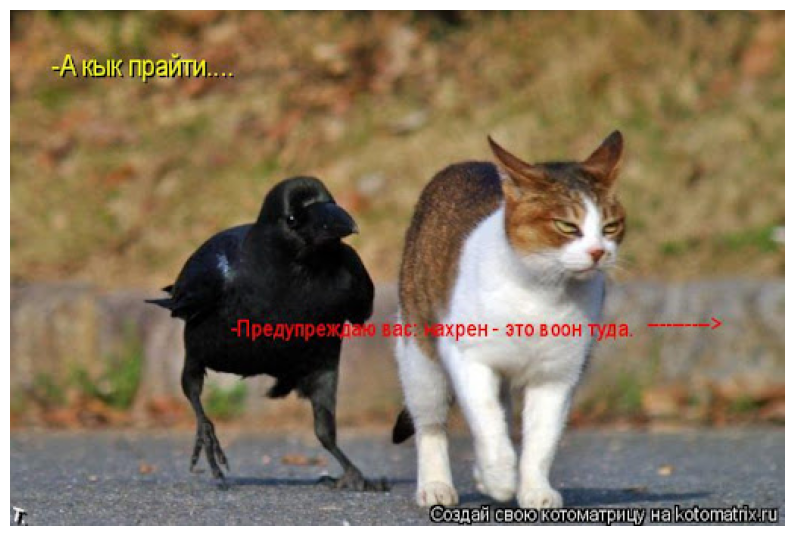

А ты знаешь, что это за кот?


In [7]:
image_path = "/home/alexey/Downloads/unnamed.jpg"
image = Image.open(image_path)
# image = None

if image is not None:
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

# prompt = "Извлеки весь текст из изображения."
prompt = "Что на изображении?"

out = model.inference(
    text=prompt,
    image=image,
    do_sample=False,
    max_new_tokens=256,
    temperature=0.7,
    repetition_penalty=1.05
)

print(out)

In [4]:
dbg = model.debug_multimodal_inputs(text=prompt, image=image)
print(dbg)

eff = model.debug_visual_embedding_effect(text=prompt, image=image)
print(eff)

{'vision_backend': 'gemma4', 'vision_name': '/media/alexey/HDDLargeData/models/VLM/gemma-4-E4B/', 'projector_type': 'mlp', 'connector_llm_name': None, 'connector_llm_dtype': 'auto', 'connector_use_text_prefix': False, 'connector_llm_use_qlora': False, 'connector_is_peft': False, 'connector_is_quantized': False, 'normalize_visual_embeddings': True, 'visual_embedding_target_norm': 0.8905801773071289, 'num_images': 1, 'image_token': '[image_token]', 'image_token_id': 128004, 'prompt_image_token_count': 1, 'input_image_token_count': 264, 'visual_token_count': 264, 'prompt_token_length': 1042, 'merged_sequence_length': 1305, 'has_inputs_embeds': True, 'inputs_embeds_shape': (1, 1305, 1536), 'attention_mask_shape': (1, 1305), 'visual_embed_norm_mean': 0.890625, 'text_embed_norm_mean': 0.86328125, 'visual_to_text_norm_ratio': 1.0316742081447965, 'visual_norm_warning': None}
{'has_inputs_embeds': True, 'visual_token_count': 264, 'max_abs_logit_diff': 24.9375, 'mean_abs_logit_diff': 2.850412130